# VENTUREGENESIS — Failure Prediction Model

**Risk Heuristics Layer (System_Design.md §4.2).**

A startup-failure classifier pooled across both project datasets:

| Class | Source | Meaning |
|---|---|---|
| **1 — failure** | `failory_dataset_yc_format.csv` **+** YC `status == "Inactive"` | documented failures + YC shutdowns |
| **0 — success** | YC `status ∈ {Active, Acquired, Public}` | companies still operating / exited |

### Why this is meaningful (and the earlier Model A wasn't)
The previous `Failory-vs-YC` framing collapsed into a *dataset detector* — the label
equalled the file of origin, so a single split on `stage == null` scored a fake 1.0 AUC.
Here the failure class is drawn from **both** files (Failory failures *and* YC-Inactive),
so file-of-origin no longer separates the classes. We additionally:

1. **Train the primary model on a leakage-safe feature set** — only fields comparable
   across both sources: `text` (pitch), `team_size`, `months_since_launch`. The
   source-tell fields (industry/stage taxonomies, batch-age, constant boolean flags)
   are excluded from the primary model.
2. **Report the within-YC test-slice AUC** (§8) as the honest headline — performance on
   YC-only test rows (Inactive vs. survivors), which carry no cross-source artifact.

Every score is a **heuristic risk indicator (0–100)** tagged `is_heuristic = True`.

## 0 · Setup

In [1]:
import re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RNG = 42
REFERENCE_YEAR = 2026

HERE = Path.cwd()
DATA = next(
    p for p in [HERE / "data", HERE.parent / "data"]
    if (p / "yc_companies_algolia.csv").exists()
)
MODELS = (DATA.parent / "models"); MODELS.mkdir(exist_ok=True)
print("data dir :", DATA)
print("models   :", MODELS)

data dir : /Users/yadnyesh/Desktop/A-Generative-Intelligence-Framework-for-Autonomous-Startup-Evolution-main/data
models   : /Users/yadnyesh/Desktop/A-Generative-Intelligence-Framework-for-Autonomous-Startup-Evolution-main/models


## 1 · Load both datasets and build the pooled failure label

`failure = Failory ∪ YC-Inactive`, `success = YC survivors`. Companies appearing in
both files (Failory failure that is also a YC row) are de-duplicated on slug + lower-cased
name, keeping the Failory copy.

In [2]:
fail_raw = pd.read_csv(DATA / "failory_dataset_yc_format.csv"); fail_raw["source"] = "failory"
yc_raw   = pd.read_csv(DATA / "yc_companies_algolia.csv");      yc_raw["source"]   = "yc"

SUCCESS_STATUSES = {"Active", "Acquired", "Public"}

# YC split into failures (Inactive) and successes (survivors)
yc_inactive = yc_raw[yc_raw["status"] == "Inactive"].copy()
yc_success  = yc_raw[yc_raw["status"].isin(SUCCESS_STATUSES)].copy()

# Drop YC rows colliding with a Failory failure (avoid double-count / contradiction)
fail_keys = (set(fail_raw["slug"].dropna().astype(str))
             | set(fail_raw["name"].dropna().str.lower()))
for d in (yc_inactive, yc_success):
    collide = (d["slug"].astype(str).isin(fail_keys) | d["name"].str.lower().isin(fail_keys))
    d.drop(d[collide].index, inplace=True)

failure = pd.concat([fail_raw, yc_inactive], ignore_index=True); failure["y"] = 1
success = yc_success.copy();                                     success["y"] = 0
df = pd.concat([failure, success], ignore_index=True)

base_rate = df["y"].mean()
print(f"corpus: {len(df):,}  ({int(df['y'].sum()):,} failure / {int((1-df['y']).sum()):,} success)")
print(f"failure base rate: {base_rate:.1%}")
print("\nfailure class composition:")
print(df[df.y==1]["source"].value_counts().rename({"failory":"failory failures",
                                                    "yc":"yc-inactive failures"}))

corpus: 6,075  (1,169 failure / 4,906 success)
failure base rate: 19.2%

failure class composition:
source
yc-inactive failures    1034
failory failures         135
Name: count, dtype: int64


## 2 · Exploratory data analysis

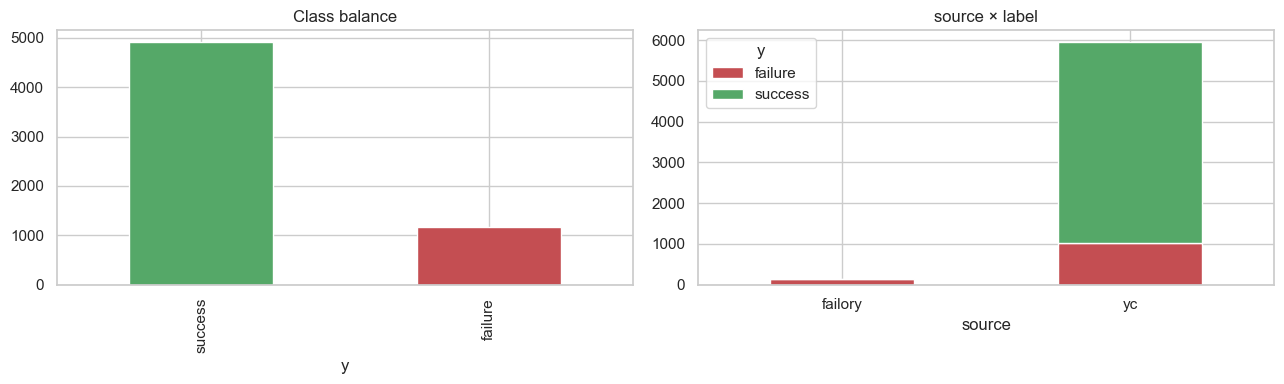

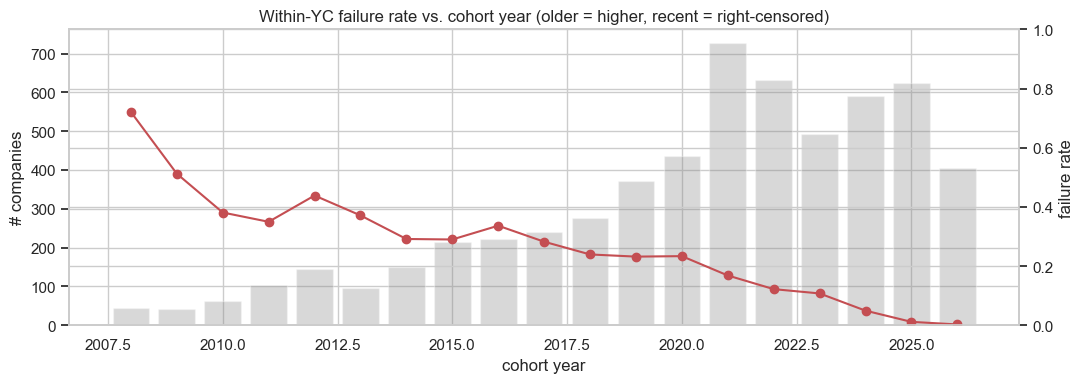

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["y"].map({0:"success",1:"failure"}).value_counts().plot.bar(
    ax=ax[0], color=["#55A868","#C44E52"]); ax[0].set_title("Class balance")
(pd.crosstab(df["source"], df["y"].map({0:"success",1:"failure"}))
   .plot.bar(stacked=True, ax=ax[1], color=["#C44E52","#55A868"]))
ax[1].set_title("source × label"); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

# Within-YC failure rate by cohort year — the real (censoring-prone) signal
def batch_year(b):
    if not isinstance(b, str): return np.nan
    m = re.search(r"(19|20)\d\d", b); return int(m.group()) if m else np.nan
yc_only = df[df.source=="yc"].copy()
yc_only["cohort"] = yc_only["batch"].map(batch_year)
by_year = yc_only.groupby("cohort")["y"].agg(["mean","count"]).dropna()
by_year = by_year[(by_year.index>=2008) & (by_year.index<=REFERENCE_YEAR)]
fig, ax1 = plt.subplots(figsize=(11,4))
ax1.bar(by_year.index, by_year["count"], alpha=.3, color="gray"); ax1.set_ylabel("# companies")
ax2 = ax1.twinx(); ax2.plot(by_year.index, by_year["mean"], "o-", color="#C44E52")
ax2.set_ylabel("failure rate"); ax2.set_ylim(0,1)
ax1.set_title("Within-YC failure rate vs. cohort year (older = higher, recent = right-censored)")
ax1.set_xlabel("cohort year"); plt.tight_layout(); plt.show()

## 3 · Feature engineering & the leakage-safe set

We engineer the full feature frame, then define two feature sets:

- **`SAFE`** *(primary model)* — `text`, `team_size`, `log_team_size`,
  `months_since_launch`. Populated and comparable in both sources.
- **`ALL`** *(comparison only)* — adds the source-correlated fields
  (`company_age_years` from batch [null for Failory], `industry`, `subindustry`,
  `stage`, `primary_region`, and the constant-False booleans). Shown in §8 to expose
  how much they inflate the score.

In [4]:
def primary_region(regs):
    return regs[0] if isinstance(regs, list) and regs else "Unspecified"

feat = pd.DataFrame(index=df.index)
feat["cohort_year"]        = df["batch"].map(batch_year)
feat["company_age_years"]  = (REFERENCE_YEAR - feat["cohort_year"]).clip(lower=0)
feat["months_since_launch"] = (
    (pd.Timestamp(f"{REFERENCE_YEAR}-06-01").timestamp() - df["launched_at"]) / (30.44*86400)
).clip(lower=0)
feat["team_size"]      = pd.to_numeric(df["team_size"], errors="coerce")
feat["log_team_size"]  = np.log1p(feat["team_size"].fillna(0))
feat["top_company"]    = df["top_company"].fillna(False).astype(int)
feat["isHiring"]       = df["isHiring"].fillna(False).astype(int)
feat["nonprofit"]      = df["nonprofit"].fillna(False).astype(int)
feat["industry"]       = df["industry"].fillna("Unknown").astype(str)
feat["subindustry"]    = df["subindustry"].fillna("Unknown").astype(str)
feat["stage"]          = df["stage"].fillna("Unknown").astype(str)
feat["primary_region"] = df["regions"].map(primary_region).astype(str)
feat["text"]           = (df["one_liner"].fillna("") + ". " + df["long_description"].fillna("")).str.strip()
for col in ["primary_region", "subindustry"]:
    keep = set(feat[col].value_counts().loc[lambda s: s>=25].index)
    feat[col] = feat[col].where(feat[col].isin(keep), "Other")

# --- feature sets ---
SAFE_NUM = ["team_size", "log_team_size", "months_since_launch"]
SAFE_CAT = []                       # all categoricals are source-tells -> excluded
TXT      = "text"
ALL_NUM  = SAFE_NUM + ["company_age_years", "top_company", "isHiring", "nonprofit"]
ALL_CAT  = ["industry", "subindustry", "stage", "primary_region"]

y      = df["y"].values
is_yc  = (df["source"] == "yc").values     # for the honest within-YC test slice
X      = feat[sorted(set(ALL_NUM + ALL_CAT)) + [TXT]]
print("SAFE features:", SAFE_NUM + [TXT])
print("ALL  features:", ALL_NUM + ALL_CAT + [TXT])

SAFE features: ['team_size', 'log_team_size', 'months_since_launch', 'text']
ALL  features: ['team_size', 'log_team_size', 'months_since_launch', 'company_age_years', 'top_company', 'isHiring', 'nonprofit', 'industry', 'subindustry', 'stage', 'primary_region', 'text']


## 4 · Stratified split (carrying the YC mask for the honest test slice)

In [5]:
idx = np.arange(len(df))
tr, te = train_test_split(idx, test_size=0.20, stratify=y, random_state=RNG)
X_tr, X_te = X.iloc[tr], X.iloc[te]
y_tr, y_te = y[tr], y[te]
yc_te      = is_yc[te]                       # boolean: which test rows are YC-only

print(f"train {len(tr):,} · test {len(te):,} · test failure rate {y_te.mean():.1%}")
print(f"within-YC test rows: {yc_te.sum():,} "
      f"({int(y_te[yc_te].sum())} failure / {int((1-y_te[yc_te]).sum())} success)")

train 4,860 · test 1,215 · test failure rate 19.3%
within-YC test rows: 1,197 (216 failure / 981 success)


## 5 · Preprocessing & models

Primary models use the **SAFE** set; one **ALL**-feature logistic model is fit purely
for the §8 inflation comparison.

In [6]:
def linear_pre(num, cat, txt=True):
    steps = [("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                               ("sc", StandardScaler())]), num)]
    if cat:
        steps.append(("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=15), cat))
    if txt:
        steps.append(("txt", TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                                             min_df=3, stop_words="english"), TXT))
    return ColumnTransformer(steps)

safe_linear = linear_pre(SAFE_NUM, SAFE_CAT, txt=True)
safe_tree   = ColumnTransformer([("num", "passthrough", SAFE_NUM)])
all_linear  = linear_pre(ALL_NUM, ALL_CAT, txt=True)

models = {
    "baseline": Pipeline([("pre", safe_linear),
                          ("clf", DummyClassifier(strategy="stratified", random_state=RNG))]),
    "logreg_text_safe": Pipeline([("pre", safe_linear),
                          ("clf", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced"))]),
    "histgb_safe": Pipeline([("pre", safe_tree),
                          ("clf", HistGradientBoostingClassifier(
                              learning_rate=0.06, max_iter=400, l2_regularization=1.0,
                              random_state=RNG, class_weight="balanced"))]),
}
for name, m in models.items():
    m.fit(X_tr, y_tr); print("fitted", name)

# All-features model (comparison only)
all_model = Pipeline([("pre", all_linear),
                      ("clf", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced"))]).fit(X_tr, y_tr)
print("fitted logreg_ALL (comparison)")

fitted baseline


fitted logreg_text_safe


fitted histgb_safe


fitted logreg_ALL (comparison)


## 6 · Evaluation

In [7]:
def evaluate(m, name):
    p = m.predict_proba(X_te)[:, 1]
    return {"model": name, "ROC_AUC": roc_auc_score(y_te, p),
            "PR_AUC": average_precision_score(y_te, p), "Brier": brier_score_loss(y_te, p)}
scores = pd.DataFrame([evaluate(m, n) for n, m in models.items()]).set_index("model")
scores.round(4)

,ROC_AUC,PR_AUC,Brier
model,,,
baseline,0.4858,0.1887,0.3259
logreg_text_safe,0.8509,0.6089,0.1369
histgb_safe,0.8440,0.6092,0.1497


In [8]:
best_name = scores.drop("baseline")["PR_AUC"].idxmax()
best = models[best_name]
print("Best (SAFE) by PR-AUC:", best_name)
p_best = best.predict_proba(X_te)[:, 1]
y_hat  = (p_best >= 0.5).astype(int)
print(classification_report(y_te, y_hat, target_names=["success","failure"]))

Best (SAFE) by PR-AUC: histgb_safe
              precision    recall  f1-score   support

     success       0.94      0.77      0.84       981
     failure       0.44      0.78      0.56       234

    accuracy                           0.77      1215
   macro avg       0.69      0.77      0.70      1215
weighted avg       0.84      0.77      0.79      1215



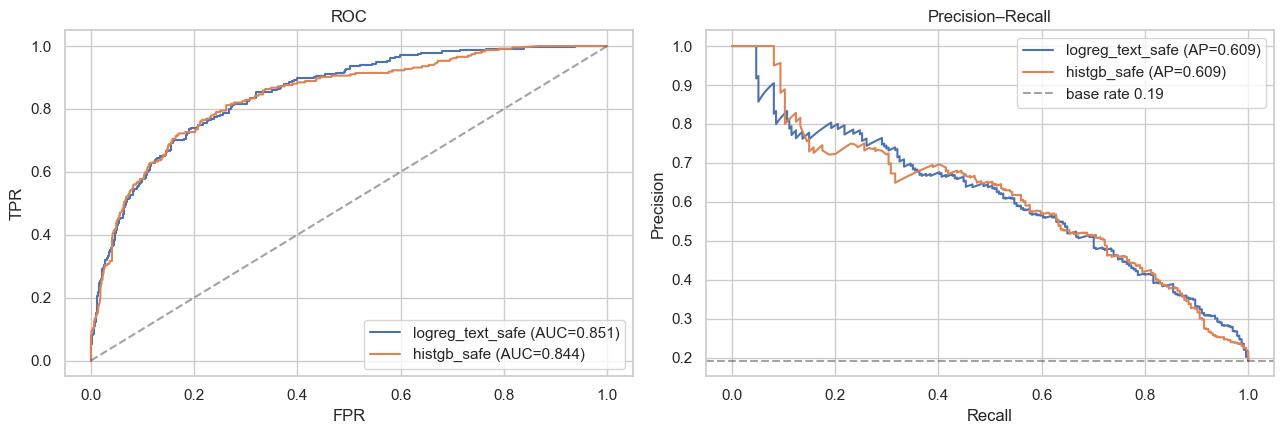

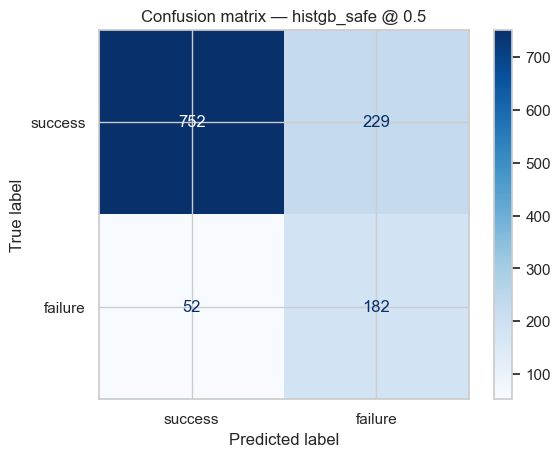

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name in ["logreg_text_safe", "histgb_safe"]:
    p = models[name].predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, p); ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te,p):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, p); ax[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_te,p):.3f})")
ax[0].plot([0,1],[0,1],"k--",alpha=.4); ax[0].set(xlabel="FPR",ylabel="TPR",title="ROC")
ax[1].axhline(y_te.mean(),ls="--",color="k",alpha=.4,label=f"base rate {y_te.mean():.2f}")
ax[1].set(xlabel="Recall",ylabel="Precision",title="Precision–Recall")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay(confusion_matrix(y_te, y_hat),
    display_labels=["success","failure"]).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix — {best_name} @ 0.5"); plt.show()

## 7 · The honest headline: within-YC test-slice AUC

Test rows that are all from YC (Inactive vs. survivors) carry **no cross-source artifact**.
The model's AUC on that slice is the defensible measure of real failure-prediction skill.
We also compare SAFE vs. ALL features and run a source-detector to show the confound is
controlled.

In [10]:
# 1) Within-YC slice (no source confound)
p_safe = best.predict_proba(X_te)[:, 1]
auc_all_rows = roc_auc_score(y_te, p_safe)
auc_yc_only  = roc_auc_score(y_te[yc_te], p_safe[yc_te])
ap_yc_only   = average_precision_score(y_te[yc_te], p_safe[yc_te])
print(f"{best_name}:")
print(f"  ROC-AUC all test rows : {auc_all_rows:.3f}")
print(f"  ROC-AUC within-YC only: {auc_yc_only:.3f}   <-- honest headline")
print(f"  PR-AUC  within-YC only: {ap_yc_only:.3f}  (base rate {y_te[yc_te].mean():.2f})")

# 2) SAFE vs ALL features (inflation from source-tells)
auc_safe = roc_auc_score(y_te, best.predict_proba(X_te)[:,1])
auc_full = roc_auc_score(y_te, all_model.predict_proba(X_te)[:,1])
auc_full_yc = roc_auc_score(y_te[yc_te], all_model.predict_proba(X_te)[yc_te,1])
print(f"\nSAFE features ROC-AUC = {auc_safe:.3f}")
print(f"ALL  features ROC-AUC = {auc_full:.3f}  (within-YC {auc_full_yc:.3f})")

# 3) Source detector on SAFE features: failory vs yc. Lower = less confounded.
src = (df["source"] == "failory").astype(int).values
det = clone(models["logreg_text_safe"]).fit(X.iloc[tr], src[tr])
auc_src = roc_auc_score(src[te], det.predict_proba(X.iloc[te])[:,1])
print(f"\nsource-detector (SAFE feats) ROC-AUC = {auc_src:.3f}")
print("(text still leaks era/style; team & launch-time are far less source-specific)")

histgb_safe:
  ROC-AUC all test rows : 0.844
  ROC-AUC within-YC only: 0.832   <-- honest headline
  PR-AUC  within-YC only: 0.547  (base rate 0.18)

SAFE features ROC-AUC = 0.844
ALL  features ROC-AUC = 0.881  (within-YC 0.871)



source-detector (SAFE feats) ROC-AUC = 0.978
(text still leaks era/style; team & launch-time are far less source-specific)


## 8 · Calibration

Brier raw=0.1497  calibrated=0.1099
ROC-AUC calibrated (within-YC) = 0.832


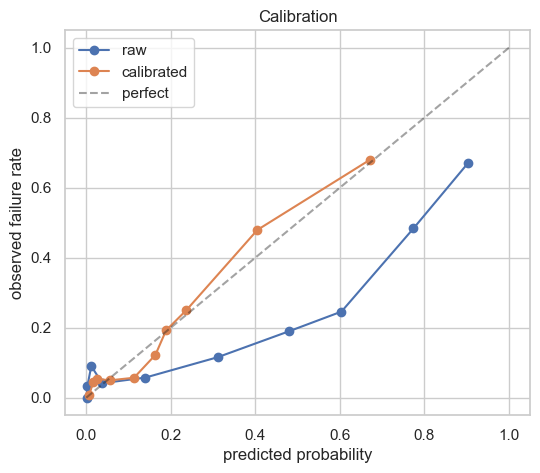

In [11]:
calibrated = CalibratedClassifierCV(best, method="isotonic", cv=5).fit(X_tr, y_tr)
p_cal = calibrated.predict_proba(X_te)[:, 1]
print(f"Brier raw={brier_score_loss(y_te,p_best):.4f}  calibrated={brier_score_loss(y_te,p_cal):.4f}")
print(f"ROC-AUC calibrated (within-YC) = {roc_auc_score(y_te[yc_te], p_cal[yc_te]):.3f}")
fig, ax = plt.subplots(figsize=(6,5))
for label, p in [("raw", p_best), ("calibrated", p_cal)]:
    frac, mean = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean, frac, "o-", label=label)
ax.plot([0,1],[0,1],"k--",alpha=.4,label="perfect")
ax.set(xlabel="predicted probability", ylabel="observed failure rate", title="Calibration")
ax.legend(); plt.show()

## 9 · What drives the prediction

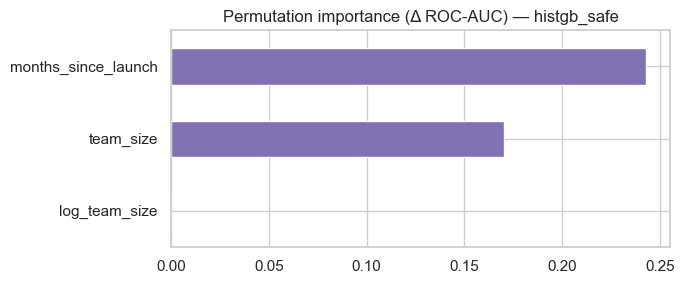

↑ pushes toward FAILURE:
wine             1.763363
app              1.754317
shut             1.588488
india            1.542245
short            1.412476
homeowners       1.311649
demand           1.298015
uber             1.246093
food delivery    1.202481
rewards          1.179057
career           1.175534
billing          1.167883
dtype: float64

↓ pushes toward SUCCESS:
acquired   -2.736882
ai         -2.444392
agents     -2.030685
apps       -1.706734
com        -1.644825
systems    -1.487964
automate   -1.386892
agent      -1.330223
free       -1.244909
100        -1.171318
better     -1.168152
hundreds   -1.158216
dtype: float64


In [12]:
# Numeric drivers (permutation importance on the safe tree model)
perm = permutation_importance(models["histgb_safe"], X_te, y_te, n_repeats=8,
                              random_state=RNG, scoring="roc_auc")
# permutation_importance scores every input column; keep the ones the safe model uses
pd.Series(perm.importances_mean, index=X_te.columns)[SAFE_NUM].sort_values().plot.barh(
    figsize=(7,3), color="#8172B3")
plt.title("Permutation importance (Δ ROC-AUC) — histgb_safe"); plt.tight_layout(); plt.show()

# Text drivers (always from the logistic text model, which owns the TF-IDF vectorizer)
lr   = models["logreg_text_safe"]
vec  = lr.named_steps["pre"].named_transformers_["txt"]
coef = lr.named_steps["clf"].coef_[0]
n_txt = len(vec.get_feature_names_out())
txt_coef = pd.Series(coef[-n_txt:], index=vec.get_feature_names_out())
print("↑ pushes toward FAILURE:"); print(txt_coef.sort_values(ascending=False).head(12))
print("\n↓ pushes toward SUCCESS:"); print(txt_coef.sort_values().head(12))

## 10 · The failure-risk indicator (simulation contract)

A callable: `startup dict -> risk payload`. Uses only the SAFE features, returns a
`0–100` indicator, tagged `is_heuristic = True`.

In [13]:
def make_predictor(model, reference_year=REFERENCE_YEAR):
    def _featurize(s):
        ts = s.get("team_size", np.nan)
        # months_since_launch: prefer launched_at, else derive from batch/age
        if s.get("launched_at"):
            msl = max(0.0, (pd.Timestamp(f"{reference_year}-06-01").timestamp()
                            - float(s["launched_at"])) / (30.44*86400))
        else:
            cy = s.get("cohort_year") or batch_year(s.get("batch"))
            msl = max(0, reference_year - cy) * 12.0 if cy else 0.0
        return pd.DataFrame([{
            "team_size": ts,
            "log_team_size": np.log1p(ts if ts and ts == ts else 0),
            "months_since_launch": msl,
            "text": (s.get("one_liner","") + ". "
                     + s.get("description", s.get("long_description",""))).strip(),
        }])[SAFE_NUM + [TXT]]

    def predict(startup: dict) -> dict:
        prob = float(model.predict_proba(_featurize(startup))[0, 1])
        return {
            "failure_risk": round(prob, 4),
            "risk_indicator": round(prob * 100, 1),
            "is_heuristic": True,
            "caveats": ["pooled_two_source", "text_era_leakage",
                        "right_censoring", "survivorship_bias"],
            "seeded_from_data": {k: startup.get(k) for k in
                                 ("team_size","launched_at","description") if k in startup},
        }
    return predict

predict_failure = make_predictor(calibrated)
examples = [
    {"team_size":4, "batch":"Winter 2016", "one_liner":"AI-native billing for SMB lenders",
     "description":"We automate billing and reconciliation for small business lenders."},
    {"team_size":2, "batch":"Summer 2012", "one_liner":"A social app for sharing playlists",
     "description":"Mobile-first social network around music playlists."},
    {"team_size":85, "batch":"Winter 2025", "one_liner":"Developer platform for AI agents",
     "description":"Infrastructure to build, deploy and observe production AI agents."},
]
for e in examples:
    r = predict_failure(e)
    print(f"{e['one_liner'][:42]:44s}  risk={r['risk_indicator']:5.1f}/100  (p={r['failure_risk']})")

AI-native billing for SMB lenders             risk= 34.6/100  (p=0.3462)


A social app for sharing playlists            risk= 61.3/100  (p=0.6126)


Developer platform for AI agents              risk=  1.2/100  (p=0.0122)


## 11 · Persist the model

In [14]:
import joblib
artifact = {
    "model": calibrated,
    "safe_num": SAFE_NUM, "txt_col": TXT,
    "reference_year": REFERENCE_YEAR,
    "label_definition": {
        "positive": "failory failures + YC Inactive",
        "negative": f"YC {sorted(SUCCESS_STATUSES)}",
    },
    "feature_policy": "leakage-safe (text + team_size + months_since_launch)",
    "metrics": {
        "roc_auc_all":     float(roc_auc_score(y_te, p_cal)),
        "roc_auc_within_yc": float(roc_auc_score(y_te[yc_te], p_cal[yc_te])),
        "pr_auc_within_yc":  float(average_precision_score(y_te[yc_te], p_cal[yc_te])),
        "brier":           float(brier_score_loss(y_te, p_cal)),
        "test_base_rate":  float(y_te.mean()),
    },
    "is_heuristic": True,
}
out = MODELS / "failure_prediction_model.joblib"
joblib.dump(artifact, out)
print("saved →", out)
print("metrics:", {k: round(v,4) for k,v in artifact["metrics"].items()})

saved → /Users/yadnyesh/Desktop/A-Generative-Intelligence-Framework-for-Autonomous-Startup-Evolution-main/models/failure_prediction_model.joblib
metrics: {'roc_auc_all': 0.8445, 'roc_auc_within_yc': 0.8325, 'pr_auc_within_yc': 0.5448, 'brier': 0.1099, 'test_base_rate': 0.1926}


## 12 · Limitations

1. **The honest number is the within-YC AUC (§7), not the all-rows AUC.** Metrics on the
   full test set are mildly inflated because the Failory failures still differ in text era
   and style; the within-YC slice removes that artifact.
2. **Residual text/era leakage.** `text` is the strongest feature and the most
   source-comparable, but Failory pitches skew older and wordier, so a little
   source signal survives in the language model. Quantified by the §7 source-detector.
3. **Right-censoring.** Recent YC cohorts have had little time to fail, so
   `months_since_launch` mixes real risk with "hasn't failed *yet*." The score is
   structurally optimistic for young companies.
4. **Survivorship / selection bias.** Both files over-represent catalogued companies;
   not a random sample of startups.
5. **Coarse failure label.** `Inactive` and "Failory failure" lump shutdowns,
   acqui-hires, and dormant-but-alive companies together.
6. **Use as a prior, not a verdict** — feeds the simulation as one heuristic input,
   always tagged `is_heuristic = True`.